# Rae2822 2D Wing Slice Model

### Import Library

In [ ]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import numpy as np

### Loading Data

In [ ]:
# angles = range(21)

folder_path = "./data/rae2822/angvar_sa/"
angles = sorted(glob.glob(f"{folder_path}*"), key=lambda x: float(x.split('\\')[-1]))
files = sorted(glob.glob(f"{folder_path}*/surface_flow.csv"))

master_df = []

for i, filepath in enumerate(angles):
    df = pd.read_csv(filepath+"/surface_flow.csv")

    # apply angles for each case
    df['AoA'] = float(angles[i].split('\\')[-1])

    master_df.append(df)

# Combine into one training set
full_data = pd.concat(master_df, ignore_index=True)
full_data = full_data[['Pressure_Coefficient', 'AoA', 'x', 'y']]
# full_data = full_data.dropna()
print(full_data[full_data.isna().any(axis=1)])


In [ ]:
print(f"Total rows: {len(full_data)}")
full_data[['Pressure_Coefficient', 'AoA', 'x', 'y']].head(300)

In [158]:
# sample_aoa = 0
# sample_case = full_data[full_data['AoA'] == sample_aoa]

# plt.figure(figsize=(10, 6))
# top_surface = sample_case[sample_case['y'] > 0].sort_values(by='x')
# bottom_surface = sample_case[sample_case['y'] <= 0].sort_values(by='x')

# plt.scatter(top_surface['x'], top_surface['Pressure_Coefficient'], color='purple', label='(Top Surface)')
# plt.scatter(bottom_surface['x'], bottom_surface['Pressure_Coefficient'],color='orange', label='(Bottom Surface)')
# plt.gca().invert_yaxis()
# plt.legend()
# plt.grid(True)
# plt.title(f"Sample Case: AoA = {sample_aoa}°")

# Model

In [69]:
# import model
import tensorflow as tf
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [70]:
full_data['AoA_rad'] = np.deg2rad(full_data['AoA'])
full_data['sin_AoA'] = np.sin(full_data['AoA_rad'])
full_data['cos_AoA'] = np.cos(full_data['AoA_rad'])

# features = ['x', 'y', 'AoA']
features = ['x', 'y', 'sin_AoA', 'cos_AoA']
target = 'Pressure_Coefficient'

In [140]:
def build_model():
    reg = tf.keras.regularizers.l2(1e-5)
    return tf.keras.Sequential([
        tf.keras.Input(shape=(4,)),
        tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=reg),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=reg),
        tf.keras.layers.Dense(1)
    ])

def build_early_stop():
    return tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,          
        restore_best_weights=True
    )

logo = LeaveOneGroupOut()

aoa_values = full_data['AoA'].values
unique_aoas = np.unique(aoa_values)
X = full_data[features].values  # shape (n*192, 3)
y = full_data[target].values    # shape (n*192, 1)

val_scores = []
train_val_ratio = []
_round = 0

for train_idx, test_idx in logo.split(X, y, aoa_values):
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    X_train_s = scaler_X.fit_transform(X_train)
    X_test_s  = scaler_X.transform(X_test)

    y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1))
    y_test_s  = scaler_y.transform(y_test.reshape(-1, 1))

    model = build_model()

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae'] # meaningful for regression
    )

    history = model.fit(
        X_train_s, y_train_s,
        epochs=200,
        validation_split=0.1,
        callbacks=[build_early_stop()],
        verbose=0
    )

    final_train = history.history['loss'][-1]
    actual_epochs = len(history.history['loss'])
    final_val   = history.history['val_loss'][-1]
    gap_ratio   = final_val / final_train

    y_pred_s = model.predict(X_test_s)
    y_pred = scaler_y.inverse_transform(y_pred_s).flatten()

    mse = np.mean((y_pred - y_test)**2)
    mae = np.mean(np.abs(y_pred - y_test))

    # score = model.evaluate(y_test, y_pred, verbose=0) # mse, mae
    val_scores.append([mse, mae])
    train_val_ratio.append(gap_ratio)
    print(f"AoA {unique_aoas[_round]} → train: {final_train:.5f} | val: {final_val:.5f} | ratio: {gap_ratio:.2f}")
    print(f"\tStopped: {actual_epochs} epochs | MSE: {mse:.5f} | MAE: {mae:.5f}")
    _round += 1


val_scores = np.array(val_scores)  # shape (44, 2)
print(f"\nMean MSE: {np.mean(val_scores[:, 0]):.4f}")
print(f"\nMean MAE: {np.mean(val_scores[:, 1]):.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
AoA 0.0 → train: 0.01283 | val: 0.06125 | ratio: 4.77
	Stopped: 44 epochs | MSE: 0.00451 | MAE: 0.05437
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
AoA 0.5 → train: 0.01389 | val: 0.08120 | ratio: 5.84
	Stopped: 36 epochs | MSE: 0.00773 | MAE: 0.07428
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
AoA 1.0 → train: 0.01479 | val: 0.06624 | ratio: 4.48
	Stopped: 30 epochs | MSE: 0.00302 | MAE: 0.04278
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
AoA 1.5 → train: 0.01098 | val: 0.03930 | ratio: 3.58
	Stopped: 58 epochs | MSE: 0.00331 | MAE: 0.05038
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
AoA 2.0 → train: 0.01397 | val: 0.04893 | ratio: 3.50
	Stopped: 38 epochs | MSE: 0.00348 | MAE: 0.04510
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
AoA 2.5 → train: 0.00950 | val: 0.03730 | ratio: 3.93
	Stopped: 90 epochs | MSE: 0.00184 | MAE: 0.02643
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
AoA 3.0 → train: 0.01022 | val: 0.04440 | ratio: 4.34
	Stopped: 74 epochs | MSE: 0.00376 | MAE: 0.04124
6/6 ━━

In [142]:
unique_aoas = np.unique(aoa_values)
for i, (aoa, score, ratio) in enumerate(zip(unique_aoas, val_scores, train_val_ratio)):
    print(f"AoA {aoa }° → MSE: {score[0]:.5f}, MAE: {score[1]:.5f}, Ratio: {ratio:.2f}")

AoA 0.0° → MSE: 0.00451, MAE: 0.05437, Ratio: 4.77
AoA 0.5° → MSE: 0.00773, MAE: 0.07428, Ratio: 5.84
AoA 1.0° → MSE: 0.00302, MAE: 0.04278, Ratio: 4.48
AoA 1.5° → MSE: 0.00331, MAE: 0.05038, Ratio: 3.58
AoA 2.0° → MSE: 0.00348, MAE: 0.04510, Ratio: 3.50
AoA 2.5° → MSE: 0.00184, MAE: 0.02643, Ratio: 3.93
AoA 3.0° → MSE: 0.00376, MAE: 0.04124, Ratio: 4.34
AoA 3.5° → MSE: 0.00238, MAE: 0.03657, Ratio: 2.77
AoA 4.0° → MSE: 0.00369, MAE: 0.04564, Ratio: 3.56
AoA 4.5° → MSE: 0.00365, MAE: 0.03625, Ratio: 3.21
AoA 5.0° → MSE: 0.00401, MAE: 0.04227, Ratio: 3.08
AoA 5.5° → MSE: 0.00472, MAE: 0.04486, Ratio: 2.64
AoA 6.0° → MSE: 0.00300, MAE: 0.04143, Ratio: 4.13
AoA 6.5° → MSE: 0.00847, MAE: 0.05508, Ratio: 4.19
AoA 7.0° → MSE: 0.00181, MAE: 0.03307, Ratio: 5.48
AoA 7.5° → MSE: 0.00480, MAE: 0.04302, Ratio: 3.43
AoA 8.0° → MSE: 0.00375, MAE: 0.03674, Ratio: 3.29
AoA 8.5° → MSE: 0.00509, MAE: 0.04759, Ratio: 3.72
AoA 9.0° → MSE: 0.00350, MAE: 0.03741, Ratio: 5.43
AoA 9.5° → MSE: 0.00539, MAE: 0

In [143]:
# train final model with full dataset
final_scaler_X = StandardScaler()
final_scaler_y = StandardScaler()

full_feature = full_data[features].values
full_target = full_data[target].values

full_X_s = final_scaler_X.fit_transform(full_feature)
full_y_s = final_scaler_y.fit_transform(full_target.reshape(-1, 1))

final_model = build_model()

final_model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
final_model.fit(
        full_X_s, full_y_s,
        epochs=200,
        validation_split=0.1,
        callbacks=[build_early_stop()],
        verbose=0
    )


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


c:\Users\KongP\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


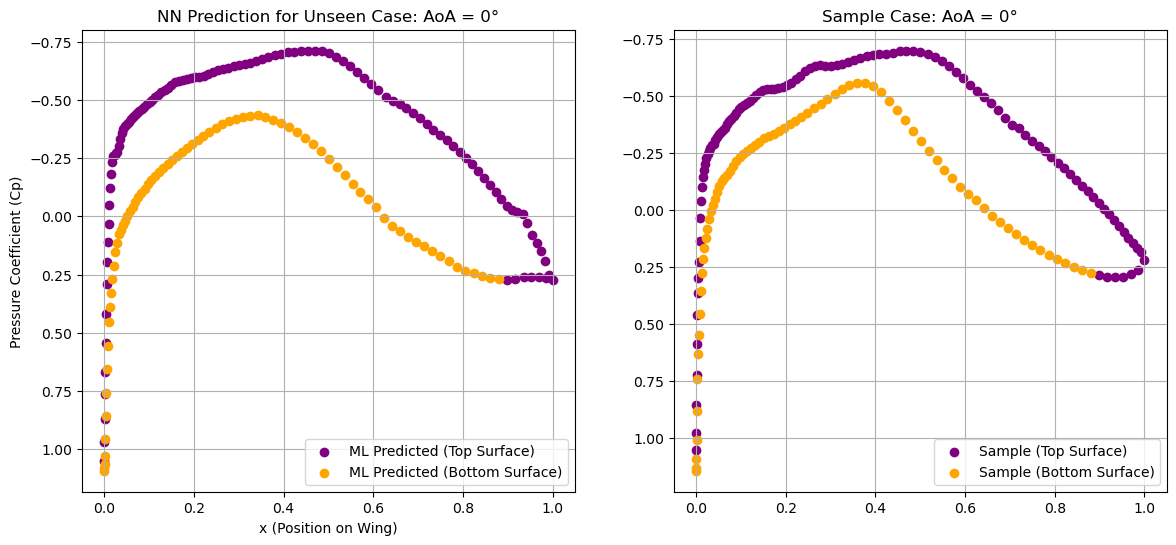

In [165]:
predict_aoa = 0

# predict_scaler_X = StandardScaler()
# predict_scaler_y = StandardScaler()

# geometry = full_data[full_data['AoA'] == 0.0][['x', 'y']].copy().reset_index(drop=True)

X_new = full_data[full_data['AoA'] == 0.0][['x', 'y']].copy().reset_index(drop=True)
X_new['sin_AoA'] = np.sin(np.deg2rad(predict_aoa))
X_new['cos_AoA'] = np.cos(np.deg2rad(predict_aoa))

# predict
X_new_s = final_scaler_X.transform(X_new[features])

Cp_predicted_s = final_model.predict(X_new_s)
Cp_predicted = final_scaler_y.inverse_transform(Cp_predicted_s)

# map back — just attach prediction to the same rows
result = X_new[['x', 'y']].copy()
result['Cp_predicted'] = Cp_predicted

# sample_aoa = 0
sample_case = full_data[full_data['AoA'] == predict_aoa]

fig, (pred, samp) = plt.subplots(1, 2, figsize=(14,6))

# plt.figure(figsize=(10, 6))
top_surface_samp = sample_case[sample_case['y'] > 0].sort_values(by='x')
bottom_surface_samp = sample_case[sample_case['y'] <= 0].sort_values(by='x')

samp.scatter(top_surface_samp['x'], top_surface_samp['Pressure_Coefficient'], color='purple', label='Sample (Top Surface)')
samp.scatter(bottom_surface_samp['x'], bottom_surface_samp['Pressure_Coefficient'],color='orange', label='Sample (Bottom Surface)')
samp.invert_yaxis()
samp.legend()
samp.grid(True)
samp.set_title(f"Sample Case: AoA = {predict_aoa}°")

top_surface_pred = result[result['y'] > 0].sort_values(by='x')
bottom_surface_pred = result[result['y'] <= 0].sort_values(by='x')

pred.scatter(top_surface_pred['x'], top_surface_pred['Cp_predicted'], color='purple', linewidth=1, label='ML Predicted (Top Surface)')
pred.scatter(bottom_surface_pred['x'], bottom_surface_pred['Cp_predicted'], color='orange', linewidth=1, label='ML Predicted (Bottom Surface)')

pred.invert_yaxis() # Invert y-axis for Aerodynamics
pred.set_title(f"NN Prediction for Unseen Case: AoA = {predict_aoa}°")
pred.set_xlabel("x (Position on Wing)")
pred.set_ylabel("Pressure Coefficient (Cp)")
pred.legend()
pred.grid(True)

In [156]:
# predict_aoa = 5

# # predict_scaler_X = StandardScaler()
# # predict_scaler_y = StandardScaler()

# # geometry = full_data[full_data['AoA'] == 0.0][['x', 'y']].copy().reset_index(drop=True)

# X_new = full_data[full_data['AoA'] == 0.0][['x', 'y']].copy().reset_index(drop=True)
# X_new['sin_AoA'] = np.sin(np.deg2rad(predict_aoa))
# X_new['cos_AoA'] = np.cos(np.deg2rad(predict_aoa))

# # predict
# X_new_s = final_scaler_X.transform(X_new[features])

# Cp_predicted_s = final_model.predict(X_new_s)
# Cp_predicted = final_scaler_y.inverse_transform(Cp_predicted_s)

# # map back — just attach prediction to the same rows
# result = X_new[['x', 'y']].copy()
# result['Cp_predicted'] = Cp_predicted

# # print(result)

# plt.figure(figsize=(10, 6))
# top_surface = result[result['y'] > 0].sort_values(by='x')
# bottom_surface = result[result['y'] <= 0].sort_values(by='x')

# plt.scatter(top_surface['x'], top_surface['Cp_predicted'], color='purple', linewidth=1, label='ML Predicted (Top Surface)')
# plt.scatter(bottom_surface['x'], bottom_surface['Cp_predicted'], color='orange', linewidth=1, label='ML Predicted (Bottom Surface)')

# plt.gca().invert_yaxis() # Invert y-axis for Aerodynamics
# plt.title(f"NN Prediction for Unseen Case: AoA = {predict_aoa}°")
# plt.xlabel("x (Position on Wing)")
# plt.ylabel("Pressure Coefficient (Cp)")
# plt.legend()
# plt.grid(True)
# plt.show()

In [ ]:
# aoa_degrees = np.linspace(0, 360, 100)
# aoa_radians = np.deg2rad(aoa_degrees)

# # 2. Apply the Trigonometric Normalization
# sin_aoa = np.sin(aoa_radians)
# cos_aoa = np.cos(aoa_radians)

# # 3. Create a side-by-side visualization
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# # --- Plot 1: The Bounded Waves ---
# ax1.plot(aoa_degrees, sin_aoa, label='sin_AoA', color='blue', linewidth=2)
# ax1.plot(aoa_degrees, cos_aoa, label='cos_AoA', color='red', linewidth=2, linestyle='--')
# ax1.set_title("1. Bounding Features between [-1, 1]")
# ax1.set_xlabel("Original Angle of Attack (Degrees)")
# ax1.set_ylabel("Normalized Feature Value")
# ax1.axhline(0, color='black', linewidth=0.8, linestyle=':')
# ax1.legend()
# ax1.grid(True, alpha=0.4)

# # --- Plot 2: The Unit Circle Projection ---
# # We use color to map back to the original angle
# cmap = plt.cm.cool
# scatter = ax2.scatter(cos_aoa, sin_aoa, c=aoa_degrees, cmap='twilight_shifted', edgecolor='k')
# ax2.set_title("2. New Feature Space (Cyclical Continuity)")
# ax2.set_xlabel("cos_AoA")
# ax2.set_ylabel("sin_AoA")
# ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')
# ax2.axvline(0, color='black', linewidth=0.8, linestyle=':')
# ax2.set_aspect('equal') # Forces the axes to be proportional (perfect circle)
# plt.colorbar(scatter, ax=ax2, label='Original AoA (Degrees)')

# plt.tight_layout()
# plt.show()